In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid")
# Завантажуємо файл
df = pd.read_csv("/train (1).csv")
print(f"Розмірність датасету: {df.shape}")
df.head()

Розмірність датасету: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
from sklearn.model_selection import train_test_split
# Видаляємо стовпець 'Id'
df_clean = df.drop(columns=['Id'])
# Відокремлюємо ознаки та цільову змінну
X = df_clean.drop(columns=['SalePrice'])
y = df_clean['SalePrice'].values
# Розбиття: Train, Validation, Test
X_train_raw, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)
print(f"Розміри вибірок:\nTrain: {X_train_raw.shape[0]}\nVal:   {X_val_raw.shape[0]}\nTest:  {X_test_raw.shape[0]}")

Розміри вибірок:
Train: 1022
Val:   219
Test:  219


Ми повинні розбити дані до масштабування чи кодування, оскільки оцінка параметрів на всьому датасеті призводить до витоку даних. Data Leakage, витік даних - це помилка в процесі підготовки даних, коли інформація з результатами експериментів потрапляє в  навчальний набір.

In [3]:
# Рахуємо кореляцію між числовими колонками та ціною тільки на вибірці Train
train_df = X_train_raw.copy()
train_df['SalePrice'] = y_train

num_cols_all = train_df.select_dtypes(include=[np.number]).columns
corr_series = train_df[num_cols_all].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("Топ-10 числових ознак за кореляцією з SalePrice:")
print(corr_series.head(10))

Топ-10 числових ознак за кореляцією з SalePrice:
OverallQual     0.784720
GrLivArea       0.689238
GarageCars      0.642689
GarageArea      0.621937
TotalBsmtSF     0.590017
1stFlrSF        0.583132
FullBath        0.549164
TotRmsAbvGrd    0.519634
YearBuilt       0.512206
YearRemodAdd    0.512190
Name: SalePrice, dtype: float64


In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
selected_num = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'LotArea']
selected_cat = ['Neighborhood', 'BldgType', 'KitchenQual']
# Заповнення пропусків
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train_num_imp = imputer_num.fit_transform(X_train_raw[selected_num])
X_val_num_imp   = imputer_num.transform(X_val_raw[selected_num])
X_test_num_imp  = imputer_num.transform(X_test_raw[selected_num])
X_train_cat_imp = imputer_cat.fit_transform(X_train_raw[selected_cat])
X_val_cat_imp   = imputer_cat.transform(X_val_raw[selected_cat])
X_test_cat_imp  = imputer_cat.transform(X_test_raw[selected_cat])
#Масштабування
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num_imp)
X_val_num_scaled   = scaler.transform(X_val_num_imp)
X_test_num_scaled  = scaler.transform(X_test_num_imp)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat_ohe = ohe.fit_transform(X_train_cat_imp)
X_val_cat_ohe   = ohe.transform(X_val_cat_imp)
X_test_cat_ohe  = ohe.transform(X_test_cat_imp)
#Об'єднання в фінальні матриці ознак
X_train = np.hstack([X_train_num_scaled, X_train_cat_ohe])
X_val   = np.hstack([X_val_num_scaled, X_val_cat_ohe])
X_test  = np.hstack([X_test_num_scaled, X_test_cat_ohe])

print(f"Фінальна розмірність ознак X_train: {X_train.shape}")

Фінальна розмірність ознак X_train: (1022, 39)


Використано параметр handle_unknown='ignore' запобігає збоям під час тестування: якщо з'являється невідома категорія, енкодер просто кодує її нулями замість виклику помилки

In [5]:
class CustomLinearRegression:
    def __init__(self):
        self.w = None
        self.b = None

    def predict(self, X):
        return np.dot(X, self.w) + self.b

    def compute_cost(self, X, y):
        # MSE
        m = len(y)
        y_hat = self.predict(X)
        cost = (1 / m) * np.sum((y_hat - y) ** 2)
        return cost
    def compute_gradients(self, X, y):
        # обчислення градієнтів за w та b
        m = len(y)
        y_hat = self.predict(X)
        error = y_hat - y
        grad_w = (2 / m) * np.dot(X.T, error)
        grad_b = (2 / m) * np.sum(error)
        return grad_w, grad_b

In [6]:
def train_linear_regression(X, y, optimizer='batch', lr=0.01, epochs=100, batch_size=32):
    m, n = X.shape
    model = CustomLinearRegression()
    model.w = np.zeros(n)
    model.b = 0.0
    cost_history = []
    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        if optimizer == 'batch':
            grad_w, grad_b = model.compute_gradients(X_shuffled, y_shuffled)
            model.w -= lr * grad_w
            model.b -= lr * grad_b

        elif optimizer == 'sgd':
            for i in range(m):
                xi = X_shuffled[i:i+1]
                yi = y_shuffled[i:i+1]
                grad_w, grad_b = model.compute_gradients(xi, yi)
                model.w -= lr * grad_w
                model.b -= lr * grad_b

        elif optimizer == 'minibatch':
            for i in range(0, m, batch_size):
                xb = X_shuffled[i:i+batch_size]
                yb = y_shuffled[i:i+batch_size]
                grad_w, grad_b = model.compute_gradients(xb, yb)
                model.w -= lr * grad_w
                model.b -= lr * grad_b
        epoch_cost = model.compute_cost(X, y)
        cost_history.append(epoch_cost)
    return model, cost_history
epochs = 120
lr = 0.01
print("Навчання Batch GD...")
model_batch, history_batch = train_linear_regression(X_train, y_train, 'batch', lr=lr, epochs=epochs)
print("Навчання Mini-batch GD (B=32)...")
model_mini, history_mini = train_linear_regression(X_train, y_train, 'minibatch', lr=lr, epochs=epochs, batch_size=32)
print("Навчання SGD...")
model_sgd, history_sgd = train_linear_regression(X_train, y_train, 'sgd', lr=0.001, epochs=epochs)

Навчання Batch GD...
Навчання Mini-batch GD (B=32)...
Навчання SGD...


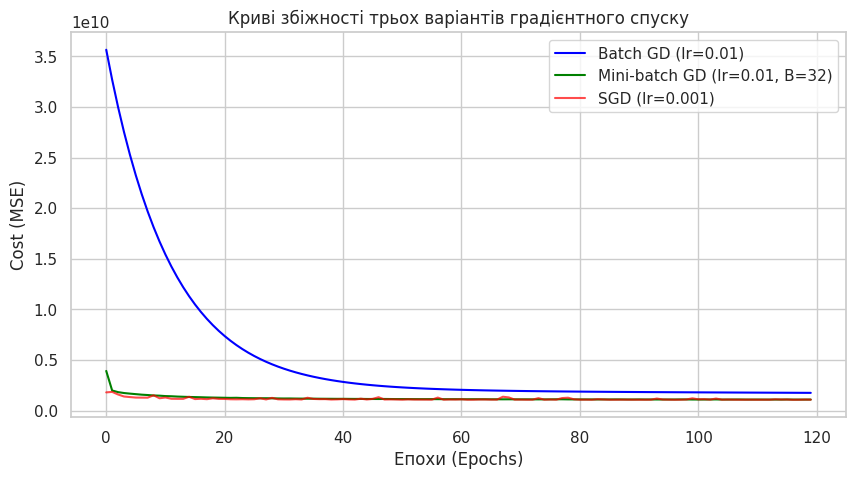

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(history_batch, label=f'Batch GD (lr={lr})', color='blue')
plt.plot(history_mini, label=f'Mini-batch GD (lr={lr}, B=32)', color='green')
plt.plot(history_sgd, label='SGD (lr=0.001)', color='red', alpha=0.7)
plt.xlabel('Епохи (Epochs)')
plt.ylabel('Cost (MSE)')
plt.title('Криві збіжності трьох варіантів градієнтного спуску')
plt.legend()
plt.show()

Найстабільніший метот -  Batch GD, він рахує градієнт по всій вибірці одразу, тому спуск плавний і без шуму.Найбільші коливання - SGD, він  оновлює ваги після кожного окремого об'єкта, через що траєкторія сильно коливається.
Малий батч дає швидкі, але хаотичні кроки, а великий батч робить навчання стабільнішим і краще використовує ресурси.
Завеликий alpha веде до перестрибування мінімуму та «вибуху» помилки, а замалий — до надто повільного навчання.

In [8]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)
models = {'Batch GD': model_batch, 'Mini-batch GD': model_mini, 'SGD': model_sgd}
print(f"{'Модель':<15} | {'R2 Train':<10} | {'R2 Val':<10} | {'R2 Test':<10}")
for name, m in models.items():
    r2_tr = r2_score(y_train, m.predict(X_train))
    r2_v  = r2_score(y_val, m.predict(X_val))
    r2_te = r2_score(y_test, m.predict(X_test))
    print(f"{name:<15} | {r2_tr:<10.4f} | {r2_v:<10.4f} | {r2_te:<10.4f}")

Модель          | R2 Train   | R2 Val     | R2 Test   
Batch GD        | 0.7079     | 0.7833     | 0.7036    
Mini-batch GD   | 0.8176     | 0.8832     | 0.8192    
SGD             | 0.8198     | 0.8850     | 0.8351    


Статистичний зміст коефіцієнту детермінації R^2 показує частку загальної дисперсії залежної змінної y, яку змогла пояснити модель.  
R^2 може бути від'ємним якщо лінійна модель прогнозує гірше, ніж просте середнє значення.  
Якщо показники R^2 Train та Test близькі, модель добре працює,як з знайомими їй даними так і з новими.

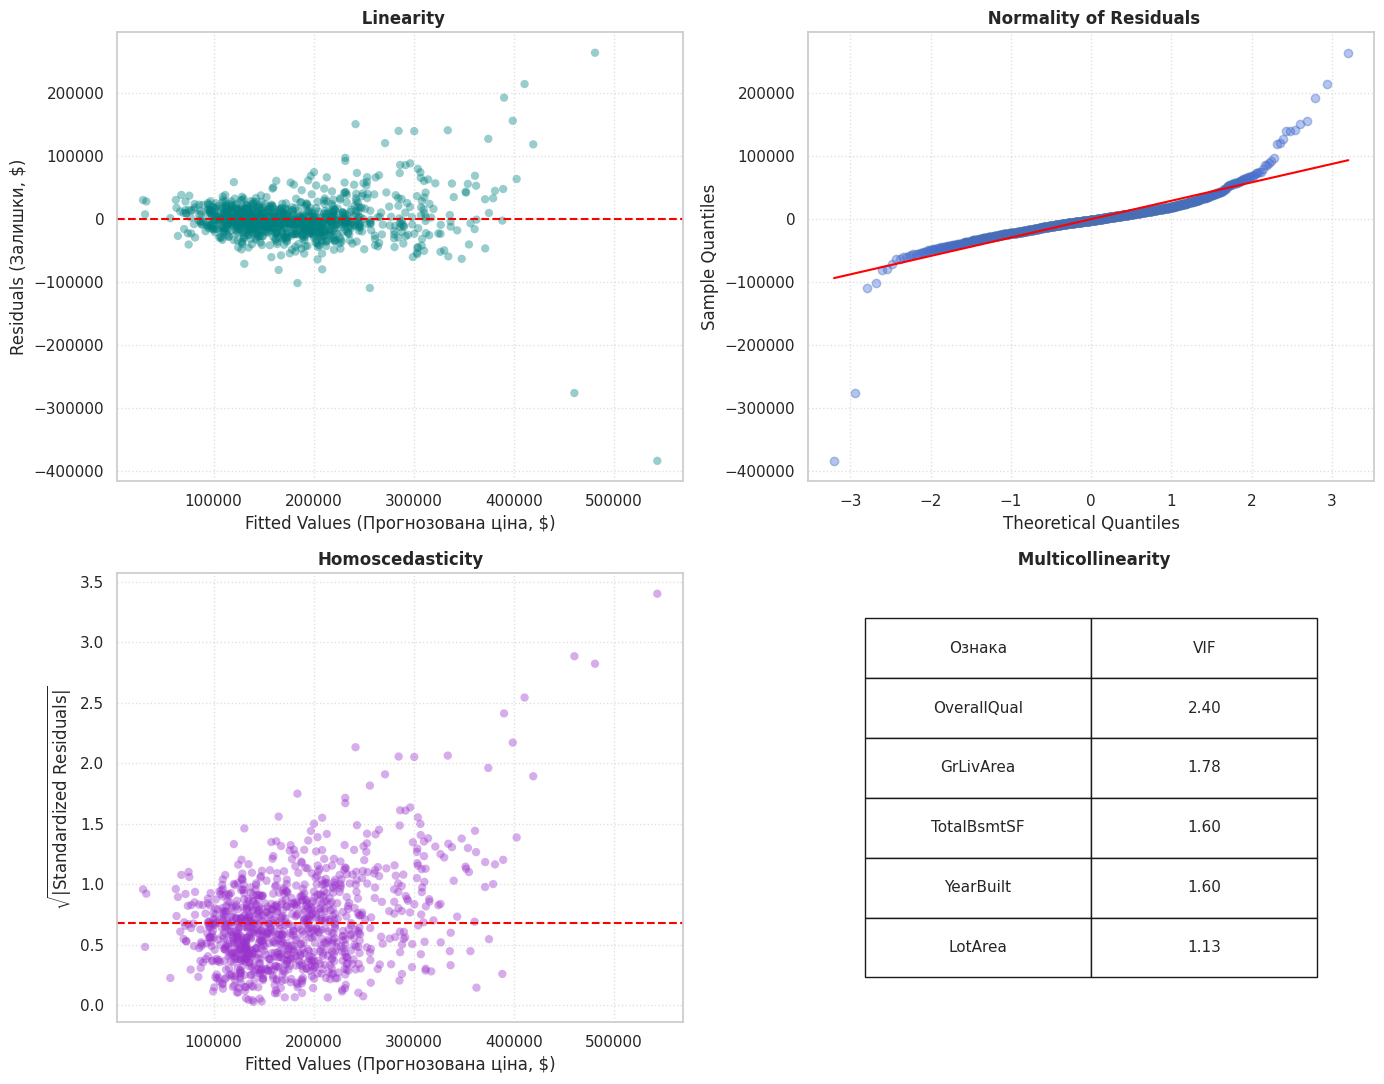

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
y_tr = np.asarray(y_train, dtype=np.float64).ravel()
X_tr = np.asarray(X_train, dtype=np.float64)
# Прогноз моделі та помилки
y_train_pred = model_mini.predict(X_tr).ravel()
residuals = y_tr - y_train_pred
fig, axs = plt.subplots(2, 2, figsize=(14, 11))
plt.subplots_adjust(hspace=0.3, wspace=0.25)
# Лінійність
axs[0, 0].scatter(y_train_pred, residuals, alpha=0.4, color='teal', edgecolor='none')
axs[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axs[0, 0].set_title(' Linearity', fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel('Fitted Values (Прогнозована ціна, $)')
axs[0, 0].set_ylabel('Residuals (Залишки, $)')
axs[0, 0].grid(True, linestyle=':', alpha=0.6)
# Нормальність
stats.probplot(residuals, dist="norm", plot=axs[0, 1])
axs[0, 1].get_lines()[0].set_markerfacecolor('royalblue')
axs[0, 1].get_lines()[0].set_alpha(0.4)
axs[0, 1].get_lines()[1].set_color('red')
axs[0, 1].set_title(' Normality of Residuals', fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel('Theoretical Quantiles')
axs[0, 1].set_ylabel('Sample Quantiles')
axs[0, 1].grid(True, linestyle=':', alpha=0.6)
# Гомоскедастичність
std_residuals = residuals / np.std(residuals)
sqrt_abs_res = np.sqrt(np.abs(std_residuals))
axs[1, 0].scatter(y_train_pred, sqrt_abs_res, alpha=0.4, color='darkorchid', edgecolor='none')
axs[1, 0].axhline(np.mean(sqrt_abs_res), color='red', linestyle='--', linewidth=1.5)
axs[1, 0].set_title('Homoscedasticity', fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel('Fitted Values (Прогнозована ціна, $)')
axs[1, 0].set_ylabel(r'$\sqrt{|\text{Standardized Residuals}|}$')
axs[1, 0].grid(True, linestyle=':', alpha=0.6)
# Відсутність мультиколінеарності
axs[1, 1].axis('off')
vif_data = []
for i, feature in enumerate(selected_num):
    vif_value = variance_inflation_factor(X_train_num_scaled, i)
    vif_data.append([feature, f"{vif_value:.2f}"])
vif_df = pd.DataFrame(vif_data, columns=['Ознака', 'VIF'])
table = axs[1, 1].table(
    cellText=vif_df.values,
    colLabels=vif_df.columns,
    cellLoc='center',
    loc='center',
    bbox=[0.1, 0.1, 0.8, 0.8]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
axs[1, 1].set_title(' Multicollinearity', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

На першому графіку залишки хаотично розкидані навколо нуля без явних вигинів. Тобто зв'язок справді лінійний і складні поліноми не потрібні.
Нормальність залишківчастково порушується. На другому графіку точки лягають на лінію в центрі, але відхиляються на краях . Це наслідок  дуже дешевих або дорогих будинків, через що довірчі інтервали можуть бути менш точними.
На третьому графіку помітна «лійка», для дорогих будинків розкид помилок зростає, тому гомоскедастичність порушується.  Модель точніше оцінює бюджетне житло, ніж елітне.Відсутність мультиколінеарності виконується, оскільки для всіх ознак VIF < 2.5 (при нормі до 5–10), і також фактори незалежні між собою і не дублюють інформацію.

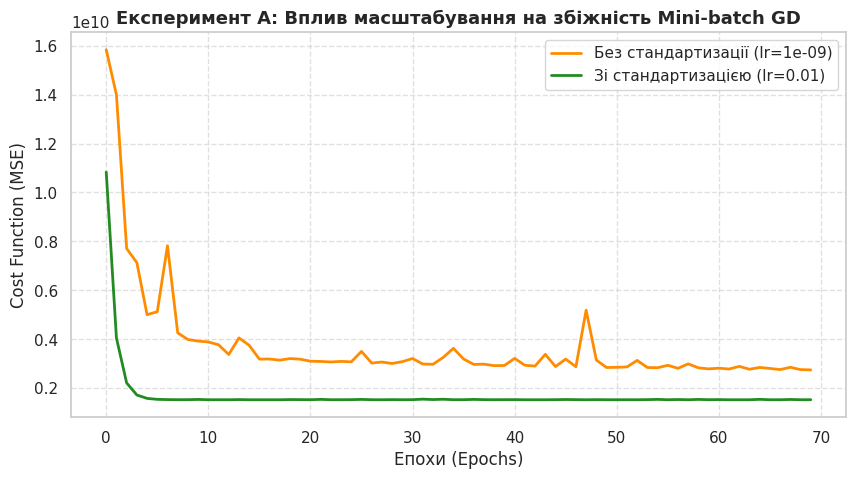

In [10]:
# Використовуються лише числові ознаки для чистоти експерименту
X_tr_unscaled = np.asarray(X_train_num_imp, dtype=np.float64)
X_tr_scaled   = np.asarray(X_train_num_scaled, dtype=np.float64)
y_tr          = np.asarray(y_train, dtype=np.float64).ravel()
# Запуск Mini-batch GD без стандартизації
lr_unscaled = 1e-9
model_unscaled, hist_unscaled = train_linear_regression(
    X_tr_unscaled, y_tr, optimizer='minibatch', lr=lr_unscaled, epochs=70, batch_size=32
)
# Запуск Mini-batch GD зі стандартизацією
lr_scaled = 0.01
model_scaled, hist_scaled = train_linear_regression(
    X_tr_scaled, y_tr, optimizer='minibatch', lr=lr_scaled, epochs=70, batch_size=32
)
# Графік порівняння швидкості збіжності
plt.figure(figsize=(10, 5))
plt.plot(hist_unscaled, label=f'Без стандартизації (lr={lr_unscaled})', color='darkorange', linewidth=2)
plt.plot(hist_scaled, label=f'Зі стандартизацією (lr={lr_scaled})', color='forestgreen', linewidth=2)
plt.title('Експеримент А: Вплив масштабування на збіжність Mini-batch GD', fontsize=13, fontweight='bold')
plt.xlabel('Епохи (Epochs)')
plt.ylabel('Cost Function (MSE)')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Зі стандартизацією модель стабільно сходиться при alpha = 0.01 за 10–15 епох. Без неї доводиться ставити крихітний крок (alpha = 10^(-9)), через що навчання практично стоїть на місці, а спроба його збільшити одразу призводить до «вибуху» градієнта.
Через непорівнянні масштаби ознак контури функції втрат сильно витягуються в овал. Градієнт завжди перпендикулярний до цих ліній, тому замість руху до центру він кидає модель від одного схилу до іншого. Масштабування перетворює овали на правильні кола — тоді найкоротший шлях до мінімуму йде по прямій.